In [3]:
from pathlib import Path
import cv2
import random
import matplotlib.pyplot as plt


ROOT = Path("/Users/mac/MeterReadAI/data/DataForTrain/water_meters")

for split in ["train", "val", "test"]:
    images = {
        p.stem for p in (ROOT / "images" / split).iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    }

    labels = {
        p.stem for p in (ROOT / "labels" / split).glob("*.txt")
    }

    print(
        f"{split}: "
        f"images={len(images)}, "
        f"labels={len(labels)}, "
        f"missing_label={len(images - labels)}, "
        f"missing_image={len(labels - images)}"
    )

train: images=995, labels=995, missing_label=0, missing_image=0
val: images=124, labels=124, missing_label=0, missing_image=0
test: images=125, labels=125, missing_label=0, missing_image=0


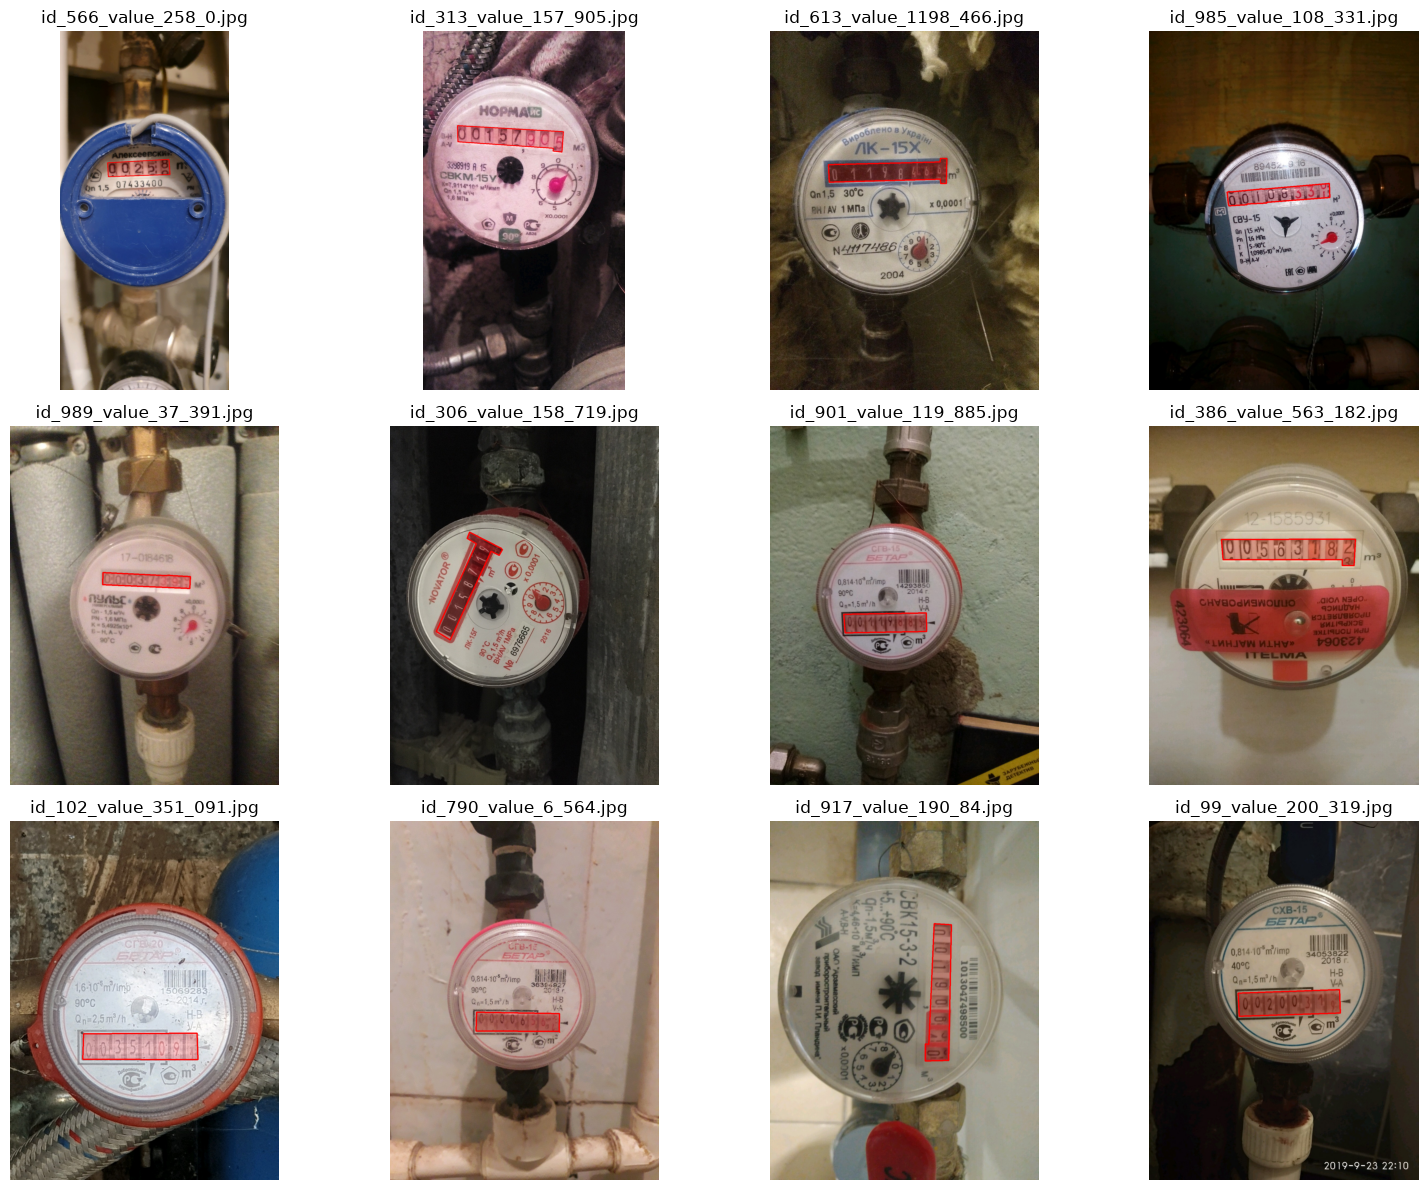

In [5]:

# =========================
# PATH
# =========================


IMAGE_DIR = ROOT / "images/train"
LABEL_DIR = ROOT / "labels/train"


# =========================
# LẤY 12 ẢNH NGẪU NHIÊN
# =========================

image_paths = list(IMAGE_DIR.glob("*.jpg"))

random.seed(42)
selected = random.sample(image_paths, min(12, len(image_paths)))


# =========================
# VISUALIZE
# =========================

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, image_path in zip(axes, selected):

    # Đọc ảnh
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    # Label tương ứng
    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as f:

            for line in f:

                values = line.strip().split()

                if len(values) < 7:
                    continue

                # Bỏ class_id
                coords = list(map(float, values[1:]))

                # Chuyển normalized → pixel
                points = []

                for i in range(0, len(coords), 2):

                    x = int(coords[i] * w)
                    y = int(coords[i + 1] * h)

                    points.append([x, y])

                # Vẽ polygon
                points = __import__("numpy").array(
                    points,
                    dtype="int32"
                )

                cv2.polylines(
                    image,
                    [points],
                    True,
                    (255, 0, 0),
                    3
                )

                # Tô nhẹ bên trong
                overlay = image.copy()

                cv2.fillPoly(
                    overlay,
                    [points],
                    (255, 0, 0)
                )

                image = cv2.addWeighted(
                    overlay,
                    0.2,
                    image,
                    0.8,
                    0
                )

    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")


plt.tight_layout()
plt.show()

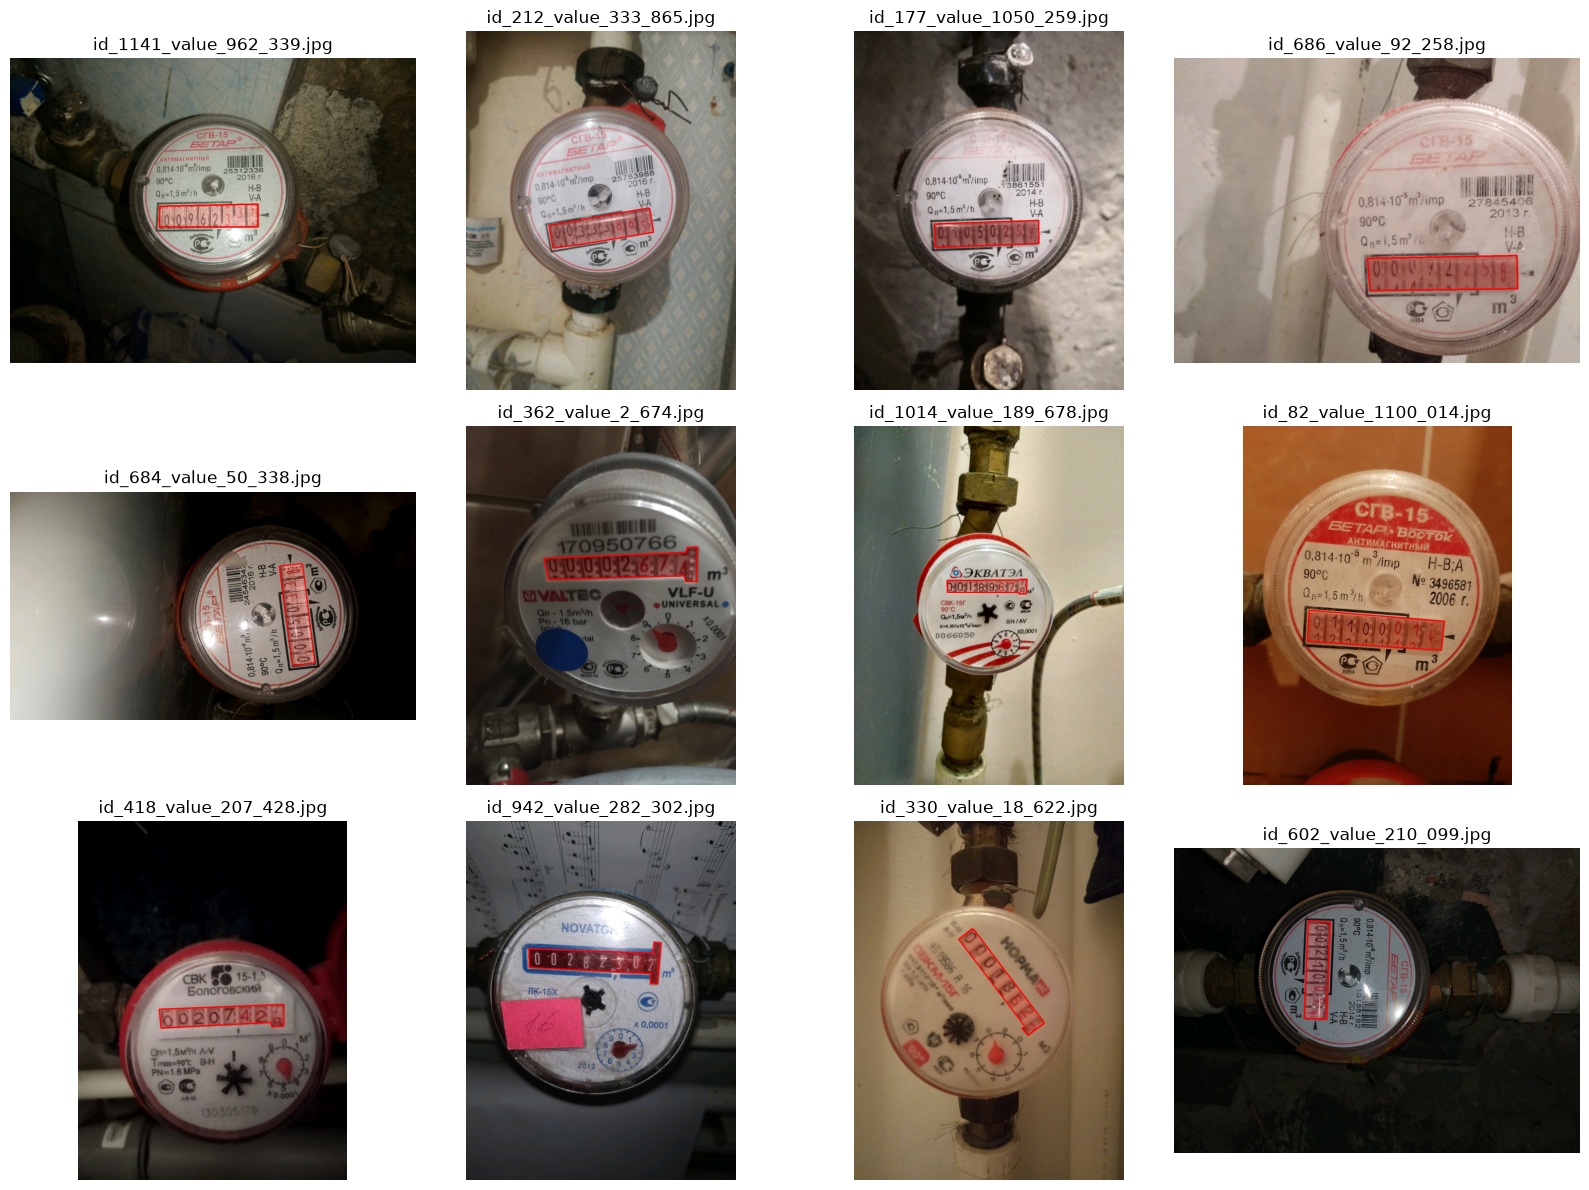

In [6]:

# =========================
# PATH
# =========================


IMAGE_DIR = ROOT / "images/test"
LABEL_DIR = ROOT / "labels/test"


# =========================
# LẤY 12 ẢNH NGẪU NHIÊN
# =========================

image_paths = list(IMAGE_DIR.glob("*.jpg"))

random.seed(42)
selected = random.sample(image_paths, min(12, len(image_paths)))


# =========================
# VISUALIZE
# =========================

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, image_path in zip(axes, selected):

    # Đọc ảnh
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    # Label tương ứng
    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as f:

            for line in f:

                values = line.strip().split()

                if len(values) < 7:
                    continue

                # Bỏ class_id
                coords = list(map(float, values[1:]))

                # Chuyển normalized → pixel
                points = []

                for i in range(0, len(coords), 2):

                    x = int(coords[i] * w)
                    y = int(coords[i + 1] * h)

                    points.append([x, y])

                # Vẽ polygon
                points = __import__("numpy").array(
                    points,
                    dtype="int32"
                )

                cv2.polylines(
                    image,
                    [points],
                    True,
                    (255, 0, 0),
                    3
                )

                # Tô nhẹ bên trong
                overlay = image.copy()

                cv2.fillPoly(
                    overlay,
                    [points],
                    (255, 0, 0)
                )

                image = cv2.addWeighted(
                    overlay,
                    0.2,
                    image,
                    0.8,
                    0
                )

    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")


plt.tight_layout()
plt.show()

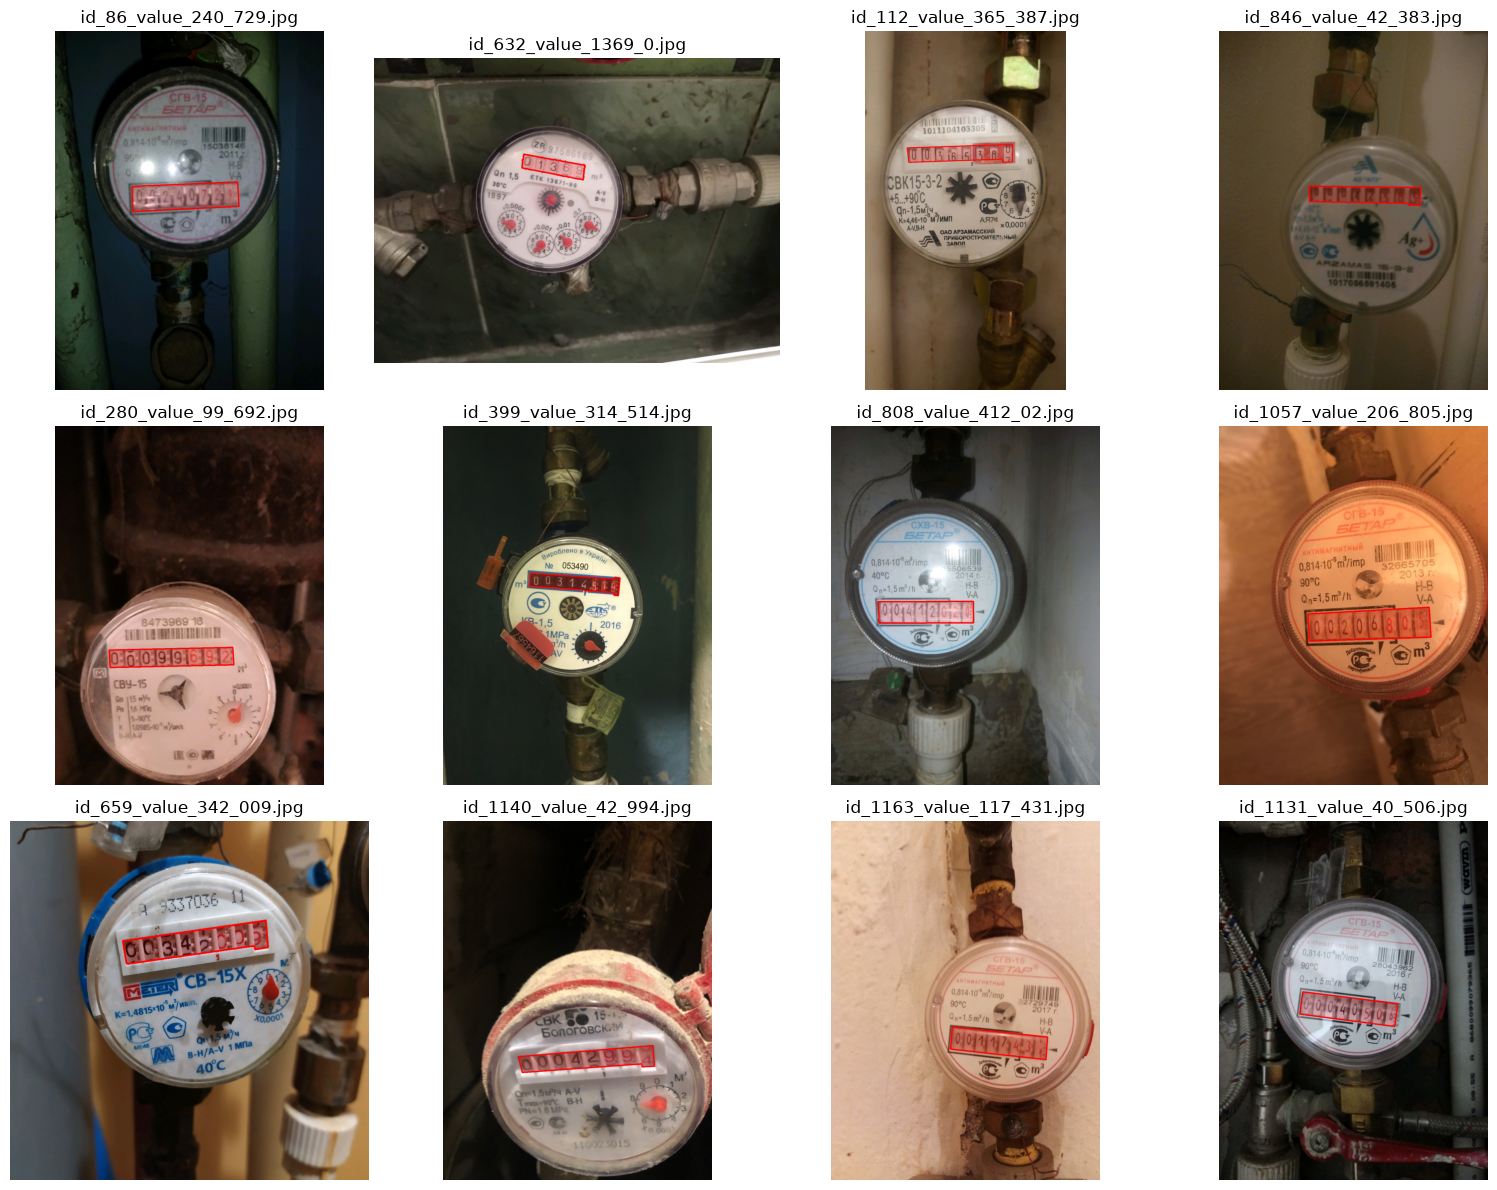

In [7]:

# =========================
# PATH
# =========================


IMAGE_DIR = ROOT / "images/val"
LABEL_DIR = ROOT / "labels/val"


# =========================
# LẤY 12 ẢNH NGẪU NHIÊN
# =========================

image_paths = list(IMAGE_DIR.glob("*.jpg"))

random.seed(42)
selected = random.sample(image_paths, min(12, len(image_paths)))


# =========================
# VISUALIZE
# =========================

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, image_path in zip(axes, selected):

    # Đọc ảnh
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    # Label tương ứng
    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as f:

            for line in f:

                values = line.strip().split()

                if len(values) < 7:
                    continue

                # Bỏ class_id
                coords = list(map(float, values[1:]))

                # Chuyển normalized → pixel
                points = []

                for i in range(0, len(coords), 2):

                    x = int(coords[i] * w)
                    y = int(coords[i + 1] * h)

                    points.append([x, y])

                # Vẽ polygon
                points = __import__("numpy").array(
                    points,
                    dtype="int32"
                )

                cv2.polylines(
                    image,
                    [points],
                    True,
                    (255, 0, 0),
                    3
                )

                # Tô nhẹ bên trong
                overlay = image.copy()

                cv2.fillPoly(
                    overlay,
                    [points],
                    (255, 0, 0)
                )

                image = cv2.addWeighted(
                    overlay,
                    0.2,
                    image,
                    0.8,
                    0
                )

    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")


plt.tight_layout()
plt.show()